# Supervised Art Gallery Solver

In [1]:
# os
import os
import sys
sys.path.append('../src')

In [36]:
# data handling
import numpy as np
import pandas as pd
# Geometry package
from   skgeom import *
from   skgeom.draw import draw
import matplotlib.pyplot as plt
## NN computing
import torch 
# our data
from   data_types import VisSample 
# types
from   typing   import Tuple
# evaluation
from  demo import polygon_demo
from  evaluate import sample_coverage

# regex
import re

# graphics
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# model
# availiable device
use_cuda = torch.cuda.is_available()
# BEGIN: List CUDA devices
if use_cuda:
    print("CUDA devices available:")
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No CUDA devices available.")
# END: List CUDA devices

CUDA devices available:
Device 0: NVIDIA GeForce RTX 3090
Device 1: NVIDIA GeForce RTX 3090


## Dataset description 

Our dataset consists of AGPIL instances obtained from [AGPPROJ - Art Gallery Problem Project](https://www.ic.unicamp.br/~cid/Problem-instances/Art-Gallery/)

In [4]:
import os
import pandas as pd

dataset_dir = '../dataset/AG/development/'
samples = {s : [f for f in os.listdir(dataset_dir+s) if f.endswith('.pol')] for s in ['train','dev','test']}
df = pd.DataFrame.from_dict(samples, orient='index').transpose()

# Add a row with the total count per column
df.loc['Total # Instances'] = df.count()

# Display the dataframe
df

,train,dev,test
0,rand-150-27.pol,rand-150-27.pol,rand-350-27.pol
1,rand-130-14.pol,simple-100-5.pol,rand-112-90.pol
2,rand-76-53.pol,rand-152-87.pol,rand-170-48.pol
3,rand-196-156.pol,rand-170-12.pol,rand-176-117.pol
4,rand-170-12.pol,rand-116-79.pol,randvon-70-16.pol
...,...,...,...
8863,rand-136-99.pol,None,None
8864,rand-120-78.pol,None,None
8865,rand-22-8.pol,None,None
8866,randvon-70-2.pol,None,None


Instances are provided as files, represented as `skgeom.polygon` with discretization points.

no. of vertices: 20, no. of points: 112


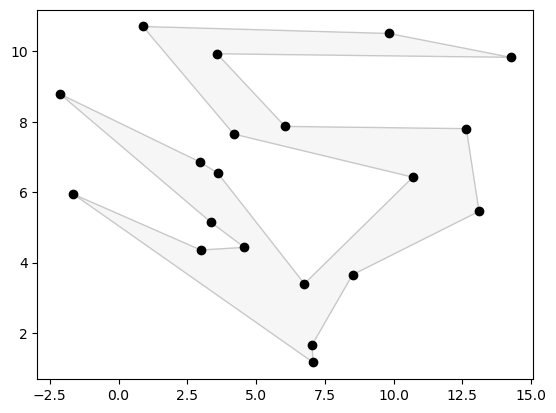

In [15]:
# test  instance
from polygon import Polygon
instance = '../dataset/AG/default/agp2009a-simplerand/20/randsimple-20-1.pol'
polygon = Polygon(filename = instance)
polygon.show(show_discretization=False)

# Pointer Network Approach

In this section, a Pointer Network is trained from labaled AGPIL dataset and used to generate a solution to an instance.


In [16]:
from evaluate import AGNetSearch, Opt

## Evaluation per instance

### Testbed 1


 * bidirectional LSTM  
 * 1 solution per instance
 * TGNet pretrained

Model loaded successfully.


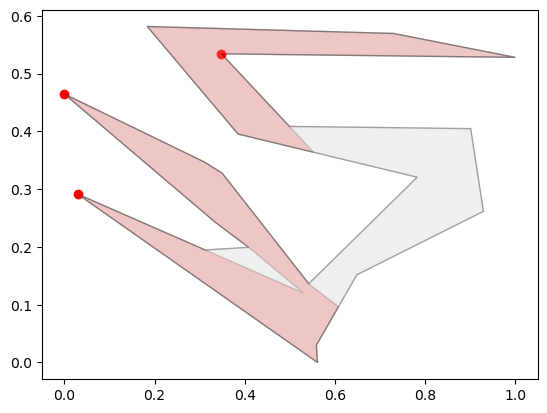

Optimal


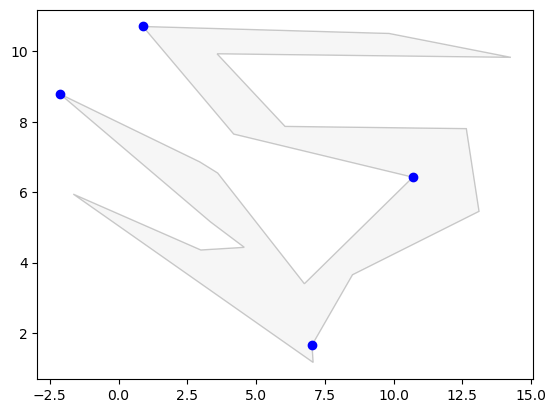

PtrNet coverage:     0.63179888,      ratio=pred/opt: 0.75000000


In [17]:
# load model
m1  = '../models/ag_clusters_numsols-1_ne-100_bs-64_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized.pt' 

#opt value
opt = Opt()
# PTrNet search
ns  = AGNetSearch(m1)

# prediction
sol_ns     = ns.predict(instance,beam_width=4)
sol_opt    = opt.predict(instance)

#print('PtrNet')
ns.show()
print('Optimal')
opt.show()

print(f'PtrNet coverage:     {ns.coverage:2.8f},      ratio=pred/opt: {len(sol_ns)/len(sol_opt):2.8f}')


# Multiple Pointer Network Approach

In [37]:
import torch

# model evaluation
from evaluate import AGMNetSearch
from evaluate import vis_predict

# define parts of architecture
from covnet  import CovNet, Encoder, Aggregator

# demonstrating examples
from demo    import show, polygon_demo3



## Model description



AGMNet consists of $k$ pointer encoder-decoder networks. It encodes polygon of $n$ vertices and decodes $k$ sets of pointers as feasible solutions to the art gallery problem. Another neural net, namely, `CovNet` approximates the coverage of the polygon. The best solution is given according tu `Covnet` best value. 



Reading model from the file.

In [38]:

# AGMNet model
agmnet_model = torch.load('../models/ag_clusters_numsols-3_ne-100_bs-64_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized.pt' )

# CovNet model
covnet_model = torch.load(f'../models/covnet.pt')

/tmp/ipykernel_228875/2049237676.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agmnet_model = torch.load('../models/ag_clusters_numsols-3_ne-100_bs-64_hs-256_tfr-0.5_w

## Experiments

### Datasets 
In this paper we use AGPLIB datasets. 



### Evaluation  

To evaluate our model we use the following metrics: 
  * **coverage** as a ratio of total area of polygon covered with predicted guards
  * **ratio** of number of guards and OPT solution. 



In [39]:
# results
results = {}

def evaluate_metrics(predictor,evaluator, batch):
    """
        evaluate metrics on test dataset
    """

    key,data = batch['name'], batch['data']

    n = len(batch['data'])
    _coverages, _ratios = np.zeros(n),np.zeros(n) 

    for i,instance in enumerate(data):
        # read sample
        print(f'Processing {instance}                         ',end='\r')
        _instance = os.path.join(dataset_dir,instance)
        sample = VisSample.read_samples(path=_instance,sol_sample=1)[0]
        
        # prediction        
        ns = AGMNetSearch(predictor,evaluator)
        
        solution = ns.predict(_instance,beam_width=4)
        
       
        _, _, _, opt, coverage = polygon_demo3(sample,solution)
        # accumulate
        _coverages[i] = coverage
        _ratios[i]    = len(solution)/len(opt)
    

    #print(f'PtrNet coverage:     {coverage:2.8f},      ratio=pred/opt: {ratio:2.8f}')

    results[key] = {
        'counts' : len(_coverages),
        'mean coverage' : np.mean(_coverages),
        'std coverage' : np.std(_coverages),         
        'mean ratio' : np.mean(_ratios),
        'std ratio'  : np.std(_ratios)
        }

    return results 


def run_evaluation_stats(testbed):
    """
        run evaluation on testbed
    """
    # list files
    df = pd.DataFrame([file for file in os.listdir(dataset_dir) if file.endswith('.pol')], columns=['name'])
    
    # check patterns
    for i, re in enumerate(testbed['regex']):
        print(f"\nPattern {i+1}/{len(testbed['regex'])}:")
        
        # read data using regex
        data = df[df.name.str.match(re)].values.squeeze().tolist()
        
        # define rows
        batch = {'name': re, 'data': data}
        
        # evaluate metrics
        results = evaluate_metrics(agmnet_model, covnet_model, batch)

    # show as dataframe
    report = pd.DataFrame.from_dict(results, orient='index')
    report.to_json(f"../results/{testbed['name']}.json")
    return report


def run_evaluation_boxplot(testbed):
    # list all instances
    files = [file for file in os.listdir(dataset_dir) if file.endswith('.pol')]
    # create df for results
    data = pd.DataFrame(columns=['name', 'type', 'coverage', 'ratio'])
    # filter out files via regex
    for regex in testbed['regex']:                
        p = re.compile(regex)        
        for file in files:
            if p.match(file): # if file matches regex
                batch = {'name': regex, 'data': [file]} # wrap data to use API
                results = evaluate_metrics(agmnet_model, covnet_model, batch)
                cov, r = results[regex]['mean coverage'], results[regex]['mean ratio'] # read mean for singletons
                data.loc[len(data)] = [file, regex, cov, r] # set instance name, type, coverage and ratio

    # Determine unique values in the 'type' column
    unique_types = data['type'].unique()
    labels = unique_types.tolist()  # Convert unique types to a list
    colors = sns.color_palette("husl", len(labels))  # Generate a color palette with enough colors

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot the first boxplot with different colors
    sns.boxplot(ax=axes[0], data=data, x="type", y="coverage", hue="type", palette=colors, legend=False)
    axes[0].set_xticks(range(len(labels)))
    axes[0].set_xticklabels(labels)

    # Plot the second boxplot with different colors
    sns.boxplot(ax=axes[1], data=data, x="type", y="ratio", hue="type", palette=colors, legend=False)
    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels)

    plt.tight_layout()
    plt.show()
            
    return data

In [40]:
results = {}
dataset_dir = '../dataset/AG/development/test'


testbed_1 = { 
    'name' : 'results_1', 
    'dataset dir' : dataset_dir,
    'regex' : [
         '.*?-[1-5]\d-', # 1-5 tens size
         '.*?-[6-9]\d-', # 6-9 tens sizes,
         '.*?-1\d\d-', # 100s size  
    ] 
}

testbed_2 = { 
    'name' : 'results_2', 
    'dataset dir' : dataset_dir,
    'regex' : [
         '.*?-2\d\d-', # 200s
         '.*?-3\d\d-', # 300s
         '.*?-4\d\d-', # 400s  
        '.*?-5\d\d-', # 500s  
    ] 
}



In [30]:
run_evaluation_stats(testbed_1)


Pattern 1/3:
Processing rand-32-3.pol                                
Pattern 2/3:
Processing rand-92-19.pol                               
Pattern 3/3:


,counts,mean coverage,std coverage,mean ratio,std ratio
.*?-[1-5]\d-,149,0.922266,0.086040,0.980050,0.188839
.*?-[6-9]\d-,219,0.907773,0.072508,0.873702,0.118026
.*?-1\d\d-,853,0.844587,0.079678,0.753397,0.119376


In [31]:
run_evaluation_stats(testbed_2)


Pattern 1/4:
Processing rand-250-6.pol                                
Pattern 2/4:
Processing randvon-300-1.pol                             
Pattern 3/4:
Processing randvon-450-13.pol                            
Pattern 4/4:


,counts,mean coverage,std coverage,mean ratio,std ratio
.*?-[1-5]\d-,149,0.922266,0.086040,0.980050,0.188839
.*?-[6-9]\d-,219,0.907773,0.072508,0.873702,0.118026
.*?-1\d\d-,853,0.844587,0.079678,0.753397,0.119376
.*?-2\d\d-,373,0.829403,0.106056,0.719606,0.150147
.*?-3\d\d-,202,0.727323,0.192078,0.582435,0.208584
.*?-4\d\d-,180,0.610088,0.217036,0.452114,0.197768
.*?-5\d\d-,129,0.530578,0.256183,0.402176,0.199306


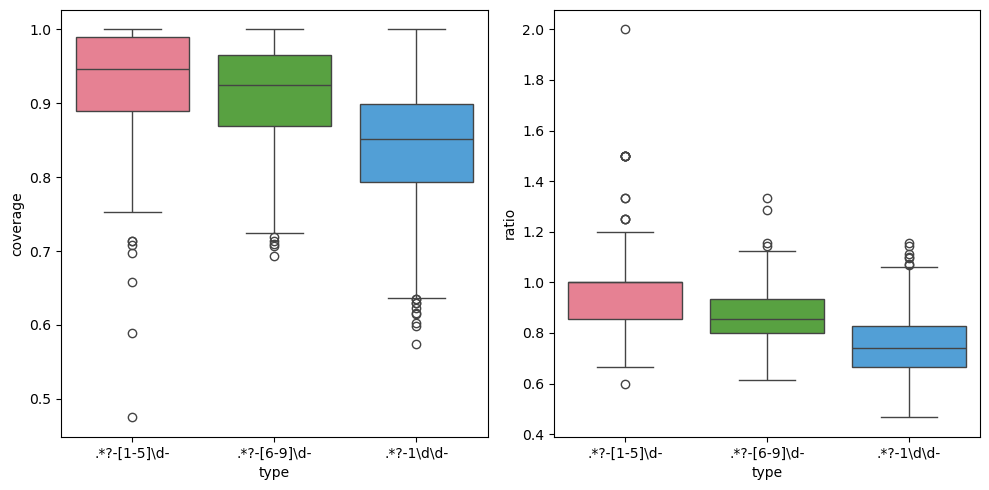

In [41]:
_ = run_evaluation_boxplot(testbed_1)

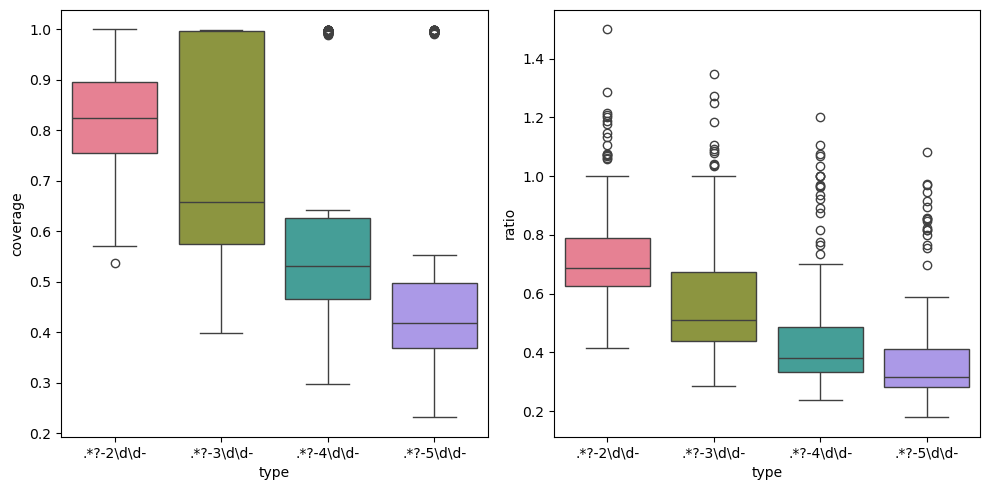

In [24]:
_ = run_evaluation_boxplot(testbed_2)

### Demonstrations

We look into specific examples to see how good the model is. 

In [25]:
# data
from data_types import VisSample 

dataset_dir = './dataset/AG/development/test'

# instance names
names = [
    'rand-8-2.pol',
    'rand-10-8.pol',
    'fat-90-1.pol',
    'rand-100-21.pol',
    'min-136-1.pol'
]


# sample wrapper
instance = os.path.join(dataset_dir,names[3])
sample = VisSample.read_samples(path=instance,sol_sample=1)[0]



Compute 5 predictions for the given sample.

In [28]:
# predict solution
seqs = vis_predict(agmnet_model,sample)
seqs

[array([ 1,  5, 20, 32, 43, 47, 51, 59, 67, 71, 81, 88]),
 array([ 1,  4,  7, 20, 31, 36, 46, 52, 64, 67, 71, 83]),
 array([ 0,  7, 20, 31, 36, 43, 52, 59, 64, 71, 76, 88])]

In [29]:
# search interface
ag = AGMNetSearch(predictor = agmnet_model,evaluator = covnet_model)
pointers = ag.predict(instance)

pointers

array([ 1,  5, 20, 32, 43, 47, 51, 59, 67, 71, 81, 88])

Visualization of the sample compared to multiple solutions. 



Optimal solution:
[PointC2(0.693878, 0.326531), PointC2(0.836735, 0.959184), PointC2(0.795918, 0.612245), PointC2(0.653061, 0.714286), PointC2(0.714286, 0.979592), PointC2(0.0612245, 0.938776), PointC2(0.469388, 0.77551), PointC2(0.0816327, 0.673469), PointC2(0.163265, 0.142857), PointC2(0.163265, 0), PointC2(0.265306, 0.102041), PointC2(0.122449, 0.244898), PointC2(0.612245, 0.0408163), PointC2(0.326531, 0.306122), PointC2(0.346939, 0.428571), PointC2(0.571429, 0.857143), PointC2(0.938776, 0.44898)]


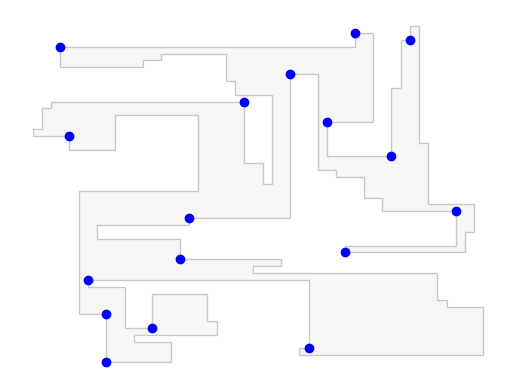

 * Optimal solution size:     17


PtrMNet solution:


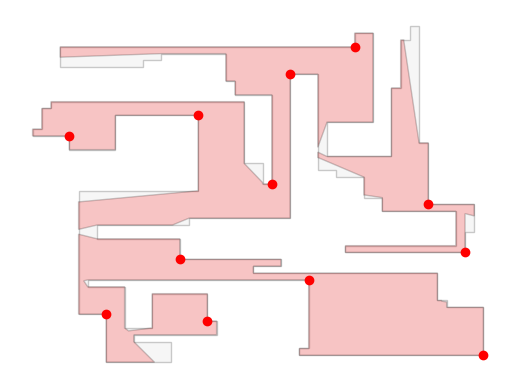

 * Predicted solution size:     12
 * PtrMNet coverage:     0.92990480,      ratio=pred/opt: 0.70588235


Other solutions


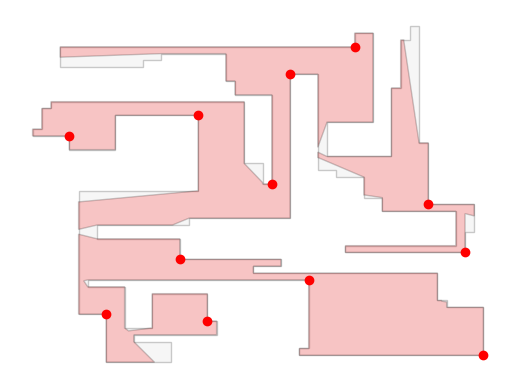

 * Predicted solution size:     12
 * PtrMNet coverage:     0.92990480,      ratio=pred/opt: 0.70588235


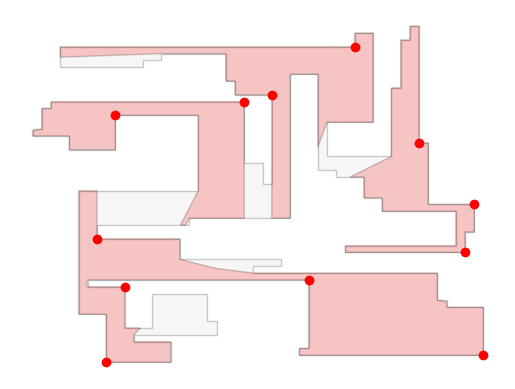

 * Predicted solution size:     12
 * PtrMNet coverage:     0.83842083,      ratio=pred/opt: 0.70588235


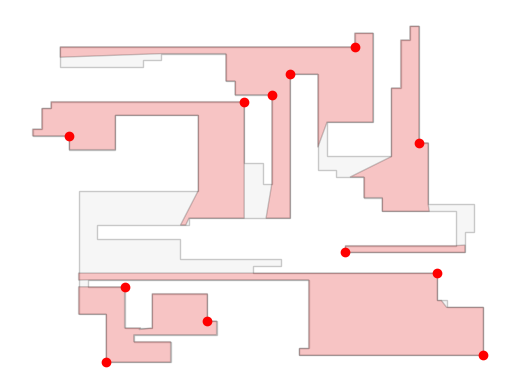

 * Predicted solution size:     12
 * PtrMNet coverage:     0.78917193,      ratio=pred/opt: 0.70588235


In [30]:
poly, region, predicted, opt, coverage = polygon_demo3(sample,pointers)
print('\n\nOptimal solution:')
print(opt)
show(poly,region,None,opt,coverage)
print('\n\nPtrMNet solution:')
show(poly,region,predicted,opt,coverage)

# other solutions
print('\n\nOther solutions')
for seq in seqs:    
    poly, region, predicted, opt, coverage = polygon_demo3(sample,seq)
    show(poly,region,predicted,opt,coverage)


## Ablation study

Several questions are needed to be answered to justify our architecture:
 1. *Why do we need Pointer Network architecture?*

     > ANSWER: It is hard to implement hard contraints in neural network models. We consider Vertex guards on Art Gallery problem which can be modeled with pointers.

 2. *What is the purpose of multiple encoders-decoders?*

     > ANSWER: Art Gallery problems doesn't have unique solutions. We tried to find different coding of solution so we can infer which solution is the best

 3. *Why do you need to use `CovNet`?*
 
     > ANSWER: `Covnet` as a regression model tries to evaluate coverage of polygon given the solution. The purpose of this is to answer can we encode such geoemtric information in NN? If yes, than our model during the inference doesn't need any geometric information.

4. *Why use only 5 solution clusters?*
    > ANSWER: It was arbitrary, but any larger number of solution clusters will make our model more architecturally complex.

# Data for the paper

In [31]:
# convert to pandas
import pandas as pd


df = pd.read_json('results/results_2.json')
print(df.to_latex(float_format="%.2f"))


\begin{tabular}{lrrrrr}
\toprule
 & counts & mean coverage & std coverage & mean ratio & std ratio \\
\midrule
.*?-[1-5]\d- & 149 & 0.92 & 0.09 & 0.98 & 0.19 \\
.*?-[6-9]\d- & 219 & 0.91 & 0.07 & 0.87 & 0.12 \\
.*?-1\d\d- & 853 & 0.84 & 0.08 & 0.75 & 0.12 \\
.*?-2\d\d- & 373 & 0.83 & 0.11 & 0.72 & 0.15 \\
.*?-3\d\d- & 202 & 0.73 & 0.19 & 0.58 & 0.21 \\
.*?-4\d\d- & 180 & 0.61 & 0.22 & 0.45 & 0.20 \\
.*?-5\d\d- & 129 & 0.53 & 0.26 & 0.40 & 0.20 \\
\bottomrule
\end{tabular}

